# Day 3 — LightGBM with engineered features

Beat the persistence-24h baseline (MAPE 4.5%) using gradient boosting on engineered features:
lag/rolling, calendar (incl. US holidays + cyclical encoding), and **lagged** Houston weather.

Also fit quantile models (q=0.1, 0.5, 0.9) for prediction intervals — coverage analysis on Day 7.

## Setup

In [1]:
import sys, json
from pathlib import Path
sys.path.insert(0, str(Path('..').resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from forecasting.data import load_demand, load_weather
from forecasting.backtest import split_train_val_test, TRAIN_END, VAL_END
from forecasting.features import build_features, FEATURE_COLS, TARGET
from forecasting.metrics import summarize
from forecasting.models import train_lgbm   # shared LightGBM helper (same defaults as notebook 05)

sns.set_theme(style='whitegrid', context='notebook')
pd.options.display.float_format = '{:,.3f}'.format

## Build features

In [2]:
demand = load_demand('ERCO')
weather = load_weather('USW00012960')   # Houston Hobby

feats = build_features(demand, weather, horizon_hours=24)
print(f'features: {len(feats):,} rows × {len(feats.columns)} cols')
feats.head(3)

/Users/visethsean/Documents/ercot-demand-forecast/forecasting/data.py:35: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(q, conn, params=(region,))
/Users/visethsean/Documents/ercot-demand-forecast/forecasting/data.py:49: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(q, conn, params=(station_id,))


features: 43,847 rows × 26 cols


,ts,demand_mwh,hour,dow,month,is_weekend,is_holiday,hour_sin,hour_cos,dow_sin,...,lag_72h,lag_168h,lag_192h,roll_24h_mean,roll_24h_std,roll_168h_mean,tmax_lag1,tmin_lag1,prcp_lag1,awnd_lag1
0,2020-01-01 00:00:00+00:00,"40,020.000",18,1,12,0,0,-1.000,-0.000,0.782,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-01-01 01:00:00+00:00,"41,642.000",19,1,12,0,0,-0.966,0.259,0.782,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2020-01-01 02:00:00+00:00,"40,925.000",20,1,12,0,0,-0.866,0.500,0.782,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# Drop rows with missing lags / rolling stats (early-train period)
feats_clean = feats.dropna(subset=FEATURE_COLS + [TARGET])
print(f'after dropna: {len(feats_clean):,} rows')

# Temporal split
train, val, test = split_train_val_test(feats_clean, ts_col='ts')
for name, part in [('train', train), ('val', val), ('test', test)]:
    print(f'{name:5s} {len(part):>6,} rows  ({part.ts.min()} → {part.ts.max()})')

after dropna: 43,583 rows
train 30,431 rows  (2020-01-09 00:00:00+00:00 → 2023-06-30 23:00:00+00:00)
val    4,368 rows  (2023-07-01 00:00:00+00:00 → 2023-12-31 23:00:00+00:00)
test   8,784 rows  (2024-01-01 00:00:00+00:00 → 2024-12-31 23:00:00+00:00)


## Point forecast (q=0.5)

In [4]:
def make_xy(df):
    return df[FEATURE_COLS], df[TARGET]

X_train, y_train = make_xy(train)
X_val,   y_val   = make_xy(val)
X_test,  y_test  = make_xy(test)

# Point forecast — uses the shared helper's defaults (n_estimators=1500,
# learning_rate=0.05, num_leaves=63, etc.). Override here if needed.
model = train_lgbm(X_train, y_train, X_val, y_val)
y_pred = model.predict(X_test)
summarize(y_test.to_numpy(), y_pred)

{'mape': 0.044334687327559796,
 'rmse': 3445.212994776201,
 'mae': 2415.1248334937354}

## Quantile models (0.1, 0.5, 0.9) for prediction intervals

Three separate LightGBM models, one per quantile. Each is evaluated with **pinball loss** —
an asymmetric loss tailored to a specific quantile:

```
For predicting the q-th quantile (e.g., q=0.1):
   over-predicted  →  loss = q     × |error|
   under-predicted →  loss = (1-q) × |error|
```

For `q=0.1`, over-predicting is penalized 9× more than under-predicting, so the model
settles at the 10th percentile. Lower pinball loss = better-calibrated quantile.
Compare apples to apples — q10 pinball loss only against another q10 model.

In [5]:
from forecasting.metrics import coverage, pinball_loss

quantile_preds = {}
for q in (0.1, 0.5, 0.9):
    qm = train_lgbm(X_train, y_train, X_val, y_val, quantile=q)
    quantile_preds[q] = qm.predict(X_test)

p10, p50, p90 = quantile_preds[0.1], quantile_preds[0.5], quantile_preds[0.9]

print(f'median q50 metrics: {summarize(y_test.to_numpy(), p50)}')
print(f'80% PI coverage: {coverage(y_test.to_numpy(), p10, p90):.3f}  (target 0.80)')
print(f'pinball loss q10/q50/q90: '
      f'{pinball_loss(y_test.to_numpy(), p10, 0.1):.1f} / '
      f'{pinball_loss(y_test.to_numpy(), p50, 0.5):.1f} / '
      f'{pinball_loss(y_test.to_numpy(), p90, 0.9):.1f}')

median q50 metrics: {'mape': 0.043356805836405464, 'rmse': 3390.726618417624, 'mae': 2347.100345111314}
80% PI coverage: 0.695  (target 0.80)
pinball loss q10/q50/q90: 552.4 / 1173.6 / 648.4


## Update scoreboard

In [6]:
scoreboard_path = Path('..') / 'results' / 'scoreboard.json'
scoreboard = json.loads(scoreboard_path.read_text()) if scoreboard_path.exists() else {'results': {}}

scoreboard['results']['lightgbm_point'] = {k: float(v) for k, v in summarize(y_test.to_numpy(), y_pred).items()}
scoreboard['results']['lightgbm_q50'] = {k: float(v) for k, v in summarize(y_test.to_numpy(), p50).items()}
scoreboard['results']['lightgbm_q50']['coverage_80pi'] = float(coverage(y_test.to_numpy(), p10, p90))

scoreboard_path.write_text(json.dumps(scoreboard, indent=2))
print(f'Updated {scoreboard_path}')

Updated ../results/scoreboard.json


## Feature importance

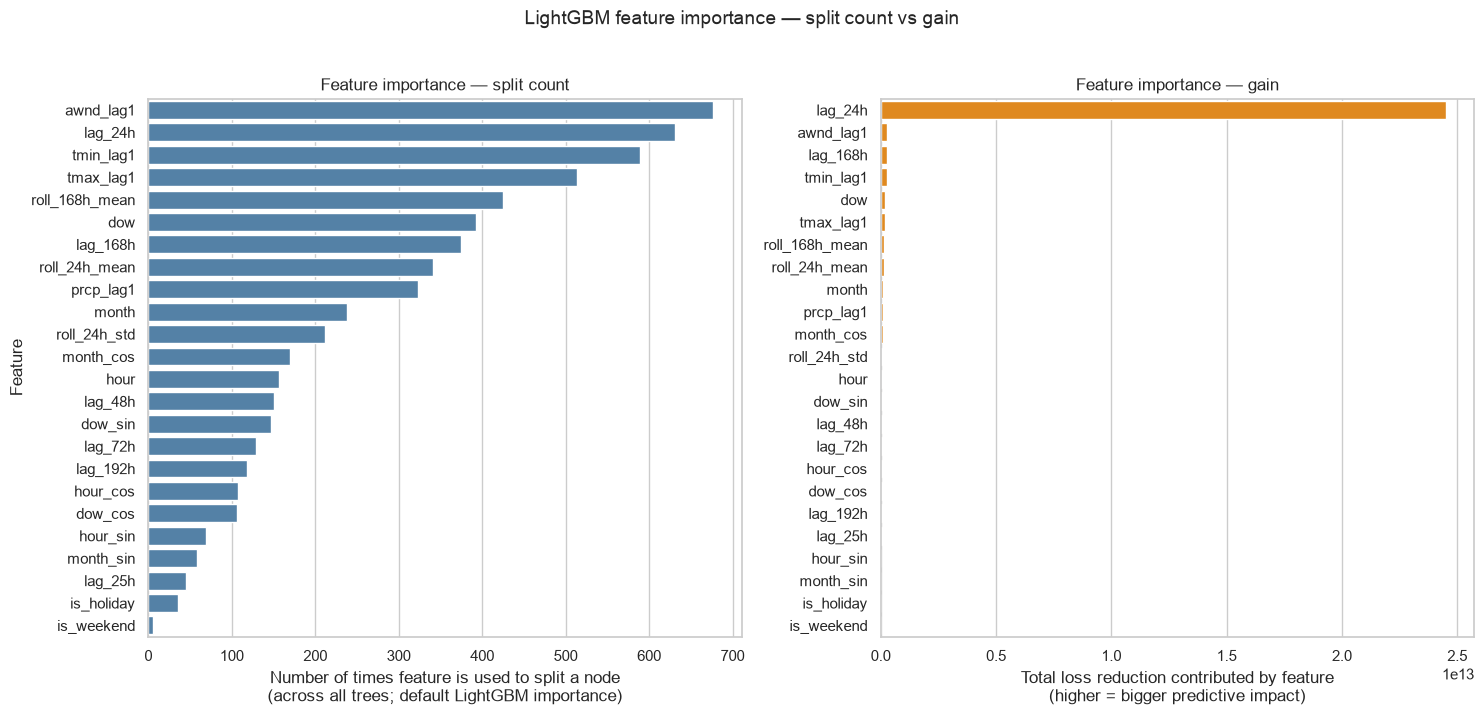

In [7]:
imp = pd.DataFrame({
    'feature': FEATURE_COLS,
    'split_count': model.feature_importances_,
    'gain':        model.booster_.feature_importance(importance_type='gain'),
})

fig, axes = plt.subplots(1, 2, figsize=(15, 7), sharey=False)

imp_split = imp.sort_values('split_count', ascending=False)
sns.barplot(data=imp_split, y='feature', x='split_count', ax=axes[0], color='steelblue')
axes[0].set_title('Feature importance — split count')
axes[0].set_xlabel('Number of times feature is used to split a node\n(across all trees; default LightGBM importance)')
axes[0].set_ylabel('Feature')

imp_gain = imp.sort_values('gain', ascending=False)
sns.barplot(data=imp_gain, y='feature', x='gain', ax=axes[1], color='darkorange')
axes[1].set_title('Feature importance — gain')
axes[1].set_xlabel('Total loss reduction contributed by feature\n(higher = bigger predictive impact)')
axes[1].set_ylabel('')

plt.suptitle('LightGBM feature importance — split count vs gain', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

## Visualize one week

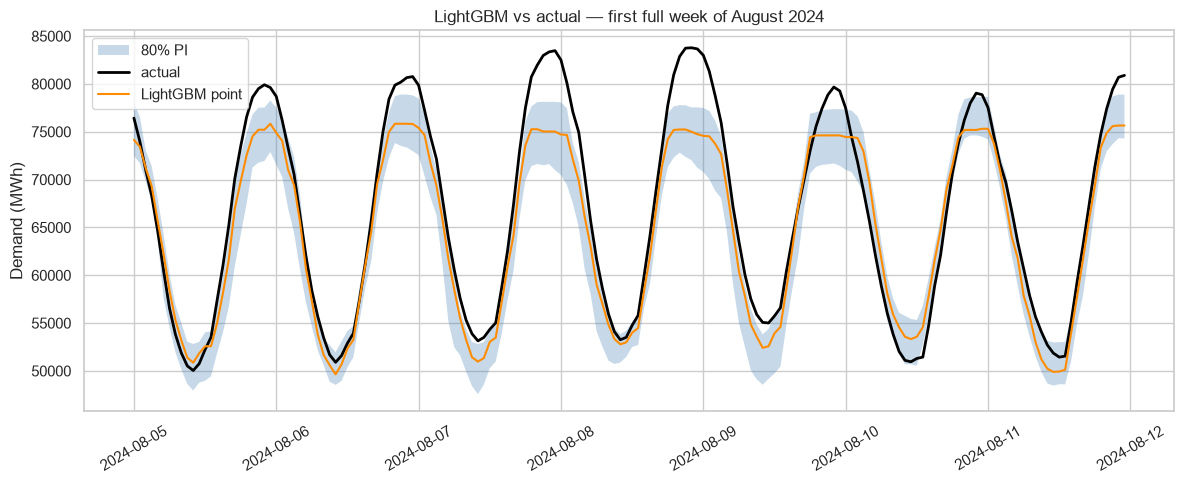

In [8]:
vis = test.copy().reset_index(drop=True)
vis['y_pred'] = y_pred
vis['p10'] = p10; vis['p90'] = p90
wk = vis[(vis.ts >= '2024-08-05') & (vis.ts < '2024-08-12')]

fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(wk.ts, wk.p10, wk.p90, color='steelblue', alpha=0.3, label='80% PI', edgecolor='none')
ax.plot(wk.ts, wk.demand_mwh, label='actual', color='black', lw=2)
ax.plot(wk.ts, wk.y_pred, label='LightGBM point', color='darkorange', lw=1.5)
ax.legend(loc='upper left')
ax.set_title('LightGBM vs actual — first full week of August 2024')
ax.set_ylabel('Demand (MWh)')
plt.xticks(rotation=30); plt.tight_layout(); plt.show()

## Takeaways for Day 5-6 (Chronos)

- LightGBM should beat persistence-24h's 4.5% MAPE — by how much depends on whether weather + calendar features add real signal.
- Watch the feature importance plot: typically `lag_24h`, `rolling_24h_mean`, and `tmax_c_lag1` dominate.
- 80% prediction interval coverage should be close to 0.80. Under-coverage = overconfident; over-coverage = wasteful intervals.
- Chronos on Day 5-6 has to beat this — and it does so zero-shot if it does, which is the headline story.